In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch





In [2]:
# ===============================
# Parámetros
# ===============================
fs = 1000        # Frecuencia de muestreo (Hz)
N = 100000       # Número de muestras
t = np.arange(N) / fs


In [3]:

# ===============================
#  Ruido térmico (blanco)
# ===============================
noise_thermal = np.random.normal(0, 1, N)

# ===============================
#  Ruido 1/f (flicker)
# Método: modelado en frecuencia
# ===============================
def generate_1_f_noise(N, fs):
    freqs = np.fft.rfftfreq(N, 1/fs)
    spectrum = np.random.normal(0, 1, len(freqs)) \
             + 1j * np.random.normal(0, 1, len(freqs))

    # Evitar división por cero
    spectrum[1:] /= np.sqrt(freqs[1:])
    spectrum[0] = 0

    noise = np.fft.irfft(spectrum, N)
    return noise / np.std(noise)

noise_flicker = generate_1_f_noise(N, fs)


In [4]:
# ===============================
# PSD (Welch)
# ===============================
f_w, psd_thermal = welch(noise_thermal, fs, nperseg=4096)
_, psd_flicker = welch(noise_flicker, fs, nperseg=4096)


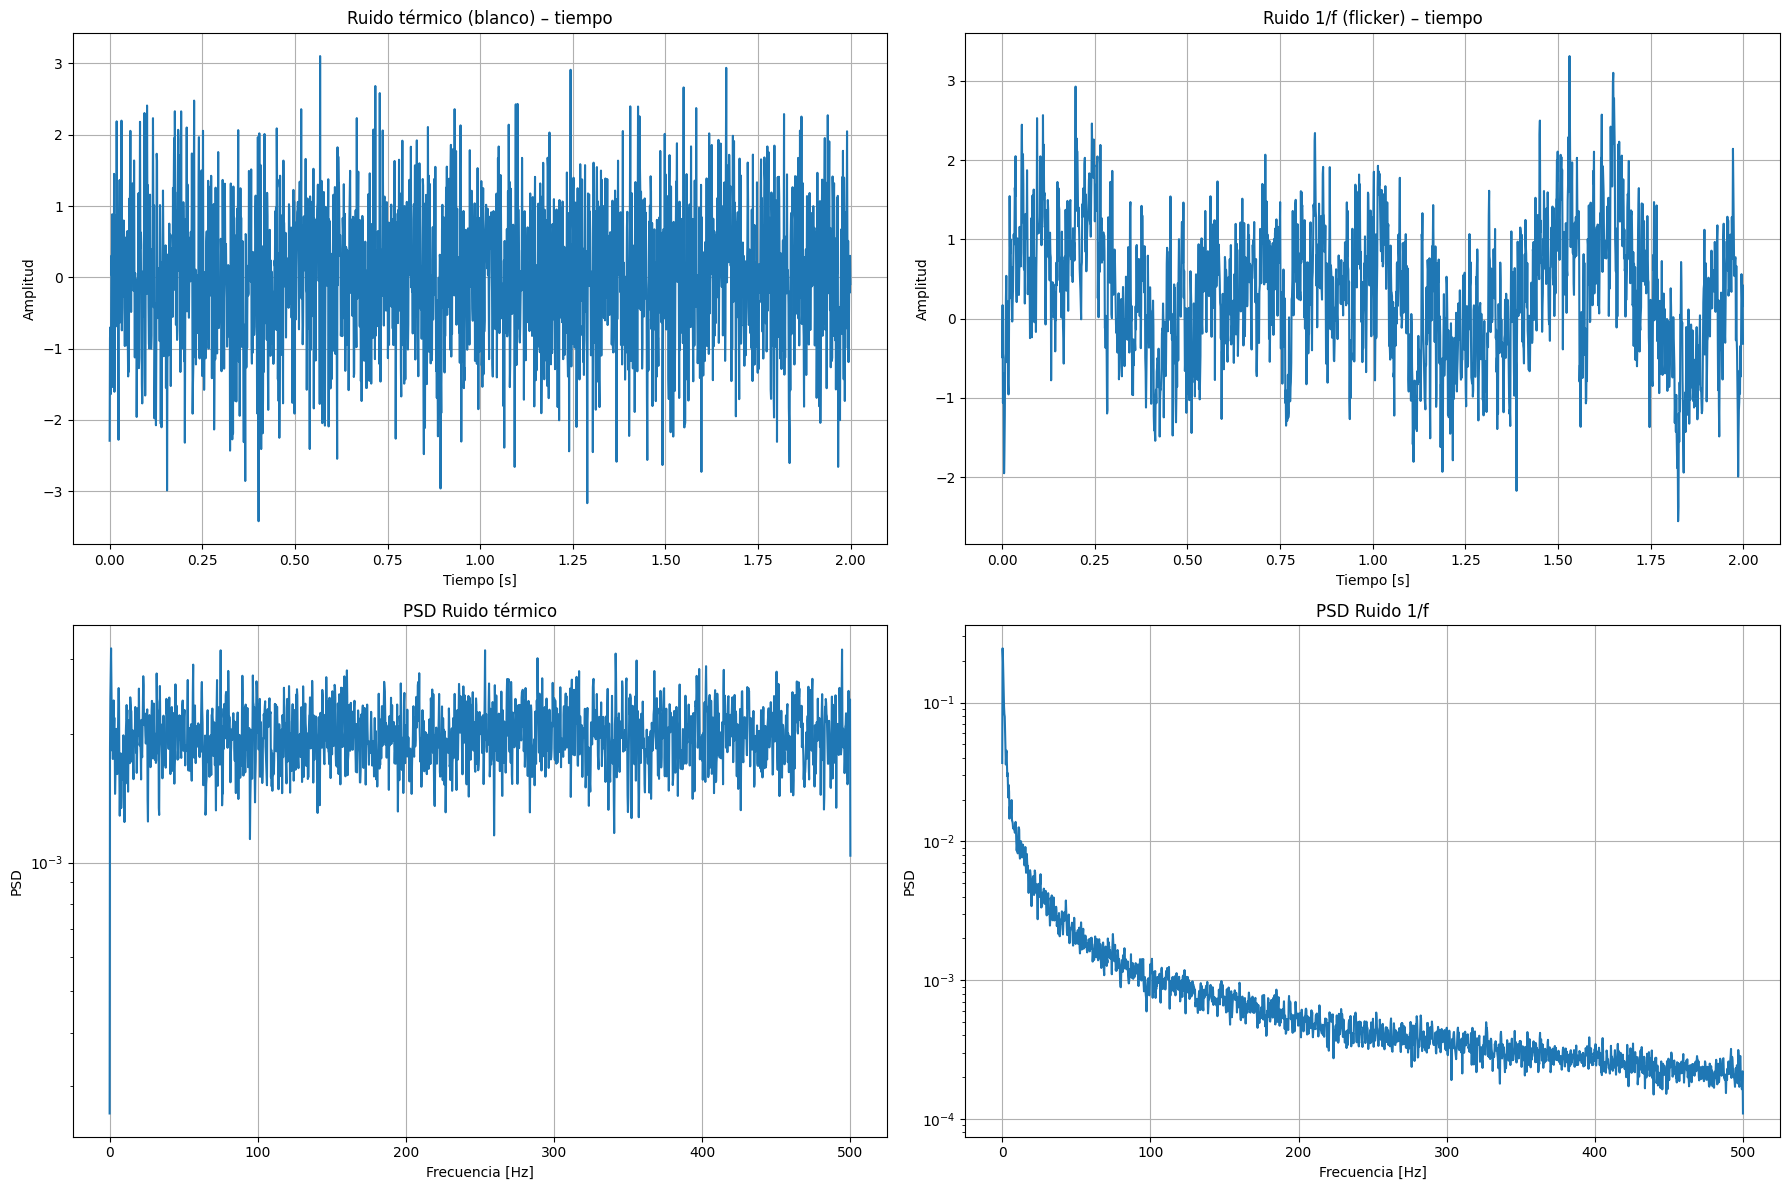

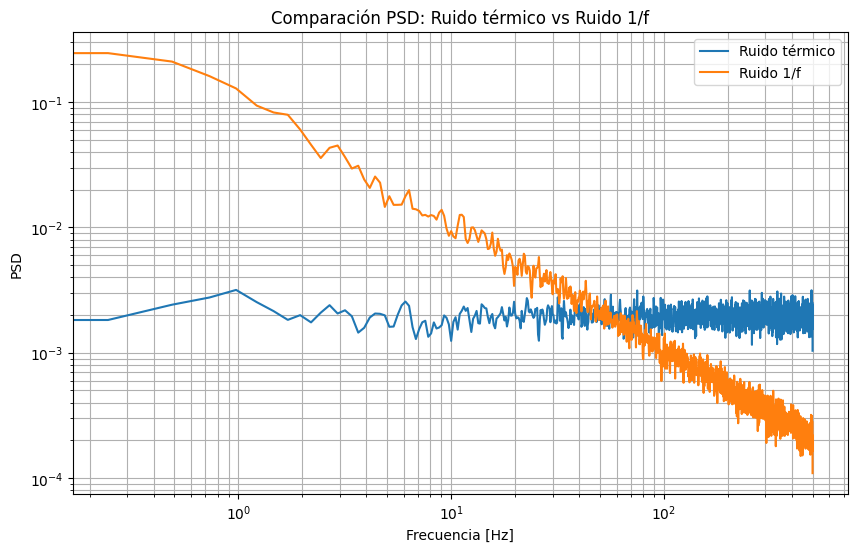

In [5]:

# ===============================
# Gráficas
# ===============================

plt.figure(figsize=(18, 12))

# ---- Tiempo ----
plt.subplot(2, 2, 1)
plt.plot(t[:2000], noise_thermal[:2000])
plt.title("Ruido térmico (blanco) – tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(t[:2000], noise_flicker[:2000])
plt.title("Ruido 1/f (flicker) – tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

# ---- Frecuencia ----
plt.subplot(2, 2, 3)
plt.semilogy(f_w, psd_thermal)
plt.title("PSD Ruido térmico")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.semilogy(f_w, psd_flicker)
plt.title("PSD Ruido 1/f")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)

plt.tight_layout()
plt.show()

# ===============================
# Comparación directa
# ===============================
plt.figure(figsize=(10, 6))
plt.loglog(f_w, psd_thermal, label="Ruido térmico")
plt.loglog(f_w, psd_flicker, label="Ruido 1/f")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.title("Comparación PSD: Ruido térmico vs Ruido 1/f")
plt.legend()
plt.grid(True, which="both")
plt.show()